In [1]:
import sys
import os

# Go up one level to the project root (add more '..' if you are deeper)
project_root = os.path.abspath('..')
print(f"This is the project_root{project_root}")
if project_root not in sys.path:
    sys.path.append(project_root)
!git clone https://github.com/tom-esplin/midi-generator-model
!pip install miditok
%cd midi-generator-model

This is the project_root/
Cloning into 'midi-generator-model'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 99 (delta 39), reused 87 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 103.84 KiB | 14.83 MiB/s, done.
Resolving deltas: 100% (39/39), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 118.8 MB/s eta 0:00:00
/content/midi-generator-model


In [2]:
!pip install -q py7zr

import shutil
from pathlib import Path
import py7zr
from google.colab import drive

drive.mount('/content/drive', force_remount=False)
DRIVE_TOKENS_ROOT = Path('/content/drive/MyDrive/midi-generator-model/saved_tokens')
LOCAL_TOKENS_ROOT = Path('tokenization/saved_tokens')
LOCAL_TOKENS_ROOT.mkdir(parents=True, exist_ok=True)

GENRE_PREFIXES = ['jazz']
selected_genres = []
for item in DRIVE_TOKENS_ROOT.iterdir():
    print(item.name)
for prefix in GENRE_PREFIXES:
    candidates = sorted(DRIVE_TOKENS_ROOT.glob(f'{prefix}_zip.7z'))
    if not candidates:
        raise FileNotFoundError(
            f"No archive matching '{prefix}_zip.7z' found in {DRIVE_TOKENS_ROOT}"
        )
    src_archive = candidates[-1]
    genre_folder_name = src_archive.stem
    dst = LOCAL_TOKENS_ROOT / genre_folder_name

    if dst.exists() and any(dst.iterdir()):
        print(f'Already extracted, skipping: {dst}')
    else:
        print(f'Extracting {src_archive.name} -> {LOCAL_TOKENS_ROOT}')
        dst.mkdir(parents=True, exist_ok=True)
        with py7zr.SevenZipFile(src_archive, mode='r') as archive:
            archive.extractall(path=LOCAL_TOKENS_ROOT)
        if not any(dst.iterdir()):
            nested = next(
                (p for p in LOCAL_TOKENS_ROOT.iterdir()
                 if p.is_dir() and p.name.startswith(f'{prefix}-') and p != dst),
                None,
            )
            if nested is not None:
                for item in nested.iterdir():
                    shutil.move(str(item), dst / item.name)
                shutil.rmtree(nested, ignore_errors=True)

    selected_genres.append(genre_folder_name)

print('\nSelected genre folders for training:')
for g in selected_genres:
    print(f'  - {g}')

from training.run_all_training import run_all_training

TEST_OPTIMIZATION_STEPS = 500
TEST_EVAL_INTERVAL = 250

losses_dict = run_all_training(
    selected_genres,
    optimization_steps=TEST_OPTIMIZATION_STEPS,
    eval_interval=TEST_EVAL_INTERVAL,
)

Mounted at /content/drive
jazz_zip.7z
classical_zip.7z
soundtrack_zip.7z
Extracting jazz_zip.7z -> tokenization/saved_tokens

Selected genre folders for training:
  - jazz_zip
Running on cuda
12.8
2.10.0+cu128
Running all training processes...

=== Genre: jazz_zip ===
Pre-loading dataset to RAM... (Ensure you have enough memory!)
Success! Converted 21341 files into tokenization/saved_tokens/jazz_zip/train/dataset.parquet
Loading and flattening entire dataset into a single stream...

--- Dataset: per_song ---

>>> Training optimized_gru


optimized_gru:  50%|█████     | 251/500 [00:38<00:37,  6.71it/s, loss=2.8971]


[optimized_gru] Step 250 | Loss 2.9210


optimized_gru: 100%|██████████| 500/500 [01:16<00:00,  6.58it/s, loss=2.7669]


[optimized_gru] Step 500 | Loss 2.7669


...


[homebrew_transformer] Step 250 | Loss 4.5784


homebrew_transformer: 100%|██████████| 500/500 [08:12<00:00,  1.01it/s, loss=4.5851]


[homebrew_transformer] Step 500 | Loss 4.5851


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

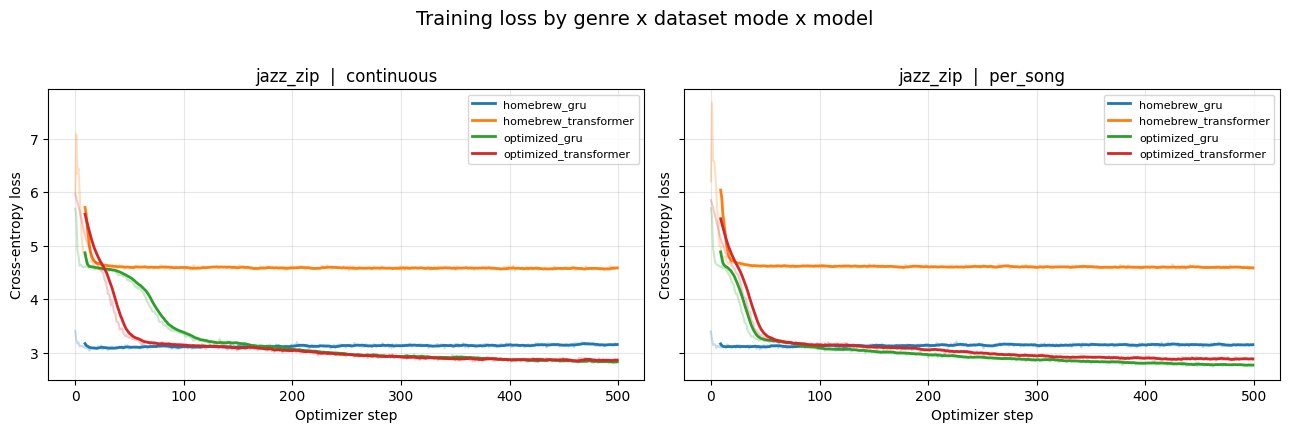


Final-loss summary:


,genre,dataset_mode,model,steps,final_loss,min_loss,mean_last_10%,stepwise,needs_mask,needs_hidden,use_amp
0,jazz_zip,continuous,optimized_gru,500,2.864258,2.806653,2.841164,False,False,True,False
1,jazz_zip,continuous,optimized_transformer,500,2.871052,2.826058,2.862960,False,True,False,True
2,jazz_zip,continuous,homebrew_gru,500,3.167032,3.041830,3.156514,True,False,True,False
3,jazz_zip,continuous,homebrew_transformer,500,4.585073,4.537936,4.577059,False,True,False,False
4,jazz_zip,per_song,optimized_gru,500,2.766901,2.745341,2.777538,False,False,True,False
5,jazz_zip,per_song,optimized_transformer,500,2.869833,2.847194,2.887637,False,True,False,True
6,jazz_zip,per_song,homebrew_gru,500,3.164485,3.064701,3.150627,True,False,True,False
7,jazz_zip,per_song,homebrew_transformer,500,4.571591,4.562542,4.594624,False,True,False,False


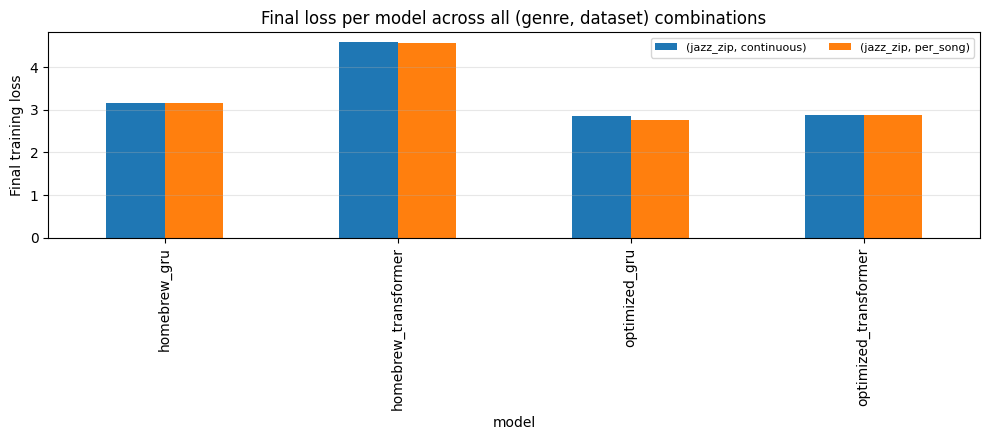

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _smooth(values, window=5):
    if len(values) < window or window <= 1:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')

genres = list(losses_dict.keys())
dataset_modes = sorted({m for g in genres for m in losses_dict[g].keys()})
model_names = sorted({
    name
    for g in genres
    for m in losses_dict[g]
    for name in losses_dict[g][m].keys()
})

color_map = {name: plt.cm.tab10(i % 10) for i, name in enumerate(model_names)}

n_rows = max(1, len(genres))
n_cols = max(1, len(dataset_modes))
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6.5 * n_cols, 4.2 * n_rows),
    squeeze=False,
    sharey=True,
)

for r, genre in enumerate(genres):
    for c, mode in enumerate(dataset_modes):
        ax = axes[r][c]
        per_model = losses_dict.get(genre, {}).get(mode, {})
        for name in model_names:
            entry = per_model.get(name)
            if not entry:
                continue
            losses = entry['train_loss']
            if not losses:
                continue
            color = color_map[name]
            ax.plot(losses, alpha=0.25, color=color)
            smoothed = _smooth(losses, window=max(1, min(10, len(losses) // 5)))
            offset = len(losses) - len(smoothed)
            ax.plot(
                np.arange(offset, offset + len(smoothed)),
                smoothed,
                label=name,
                color=color,
                linewidth=2,
            )
        ax.set_title(f'{genre}  |  {mode}')
        ax.set_xlabel('Optimizer step')
        ax.set_ylabel('Cross-entropy loss')
        ax.grid(True, alpha=0.3)
        if per_model:
            ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Training loss by genre x dataset mode x model', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

summary_rows = []
for genre in genres:
    for mode in dataset_modes:
        for name in model_names:
            entry = losses_dict.get(genre, {}).get(mode, {}).get(name)
            if not entry:
                continue
            losses = entry['train_loss']
            if not losses:
                continue
            meta = entry.get('meta', {})
            summary_rows.append({
                'genre': genre,
                'dataset_mode': mode,
                'model': name,
                'steps': entry.get('steps', len(losses)),
                'final_loss': float(losses[-1]),
                'min_loss': float(np.min(losses)),
                'mean_last_10%': float(np.mean(losses[max(1, int(len(losses) * 0.9)):])),
                'stepwise': meta.get('stepwise', False),
                'needs_mask': meta.get('needs_mask', False),
                'needs_hidden': meta.get('needs_hidden', False),
                'use_amp': meta.get('use_amp', False),
            })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ['genre', 'dataset_mode', 'final_loss']
).reset_index(drop=True)
print('\nFinal-loss summary:')
try:
    from IPython.display import display
    display(summary_df)
except ImportError:
    print(summary_df.to_string(index=False))

if not summary_df.empty:
    fig2, ax2 = plt.subplots(figsize=(10, 4.5))
    pivot = summary_df.pivot_table(
        index='model',
        columns=['genre', 'dataset_mode'],
        values='final_loss',
    )
    pivot.plot(kind='bar', ax=ax2)
    ax2.set_ylabel('Final training loss')
    ax2.set_title('Final loss per model across all (genre, dataset) combinations')
    ax2.legend(loc='upper right', fontsize=8, ncol=2)
    ax2.grid(axis='y', alpha=0.3)
    fig2.tight_layout()
    plt.show()